In [1]:
from google.colab import files
uploaded = files.upload()

Saving data_2.csv to data_2.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [8]:
df = pd.read_csv("/content/data_2.csv")

In [9]:
df.head()

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration
0,1.0,2015-02-06 22:24:17,2015-02-06 23:11:17,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,861.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:33:25,46,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,690.0
2,2.0,2015-02-16 00:11:35,2015-02-16 01:06:35,36,3.0,4,4771,3,820,1604,8.0,6.0,18.0,289.0
3,1.0,2015-02-12 03:36:46,2015-02-12 04:35:46,38,1.0,1,1525,1,1525,1525,5.0,6.0,8.0,795.0
4,1.0,2015-01-27 02:12:36,2015-01-27 02:58:36,38,1.0,2,3620,2,1425,2195,5.0,5.0,7.0,205.0


shape of the data

In [11]:
df.shape

(175777, 14)

information of data

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175777 entries, 0 to 175776
Data columns (total 14 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   market_id                                     175777 non-null  float64
 1   created_at                                    175777 non-null  object 
 2   actual_delivery_time                          175777 non-null  object 
 3   store_primary_category                        175777 non-null  int64  
 4   order_protocol                                175777 non-null  float64
 5   total_items                                   175777 non-null  int64  
 6   subtotal                                      175777 non-null  int64  
 7   num_distinct_items                            175777 non-null  int64  
 8   min_item_price                                175777 non-null  int64  
 9   max_item_price                                17

described the data

In [13]:
df.describe()

,market_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration
count,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000
mean,2.743726,35.887949,2.911752,3.204976,2697.111147,2.675060,684.965433,1160.158616,44.918664,41.861381,58.230115,546.077240
std,1.330963,20.728254,1.513128,2.674055,1828.554893,1.625681,519.882924,560.828571,34.544724,32.168505,52.731043,218.717798
min,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,-86.000000,0.000000,-4.000000,-5.000000,-6.000000,0.000000
25%,2.000000,18.000000,1.000000,2.000000,1412.000000,1.000000,299.000000,799.000000,17.000000,15.000000,17.000000,384.000000
50%,2.000000,38.000000,3.000000,3.000000,2224.000000,2.000000,595.000000,1095.000000,37.000000,35.000000,41.000000,544.000000
75%,4.000000,55.000000,4.000000,4.000000,3410.000000,3.000000,942.000000,1395.000000,66.000000,63.000000,85.000000,703.000000
max,6.000000,72.000000,7.000000,411.000000,26800.000000,20.000000,14700.000000,14700.000000,171.000000,154.000000,285.000000,2088.000000


caterigal summary

In [17]:
df.describe(include='object')

,created_at,actual_delivery_time
count,175777,175777
unique,162649,160344
top,2015-02-11 19:50:43,2015-02-15 04:18:47
freq,6,5


missing value

In [18]:
df.isnull().sum()

,0
market_id,0
created_at,0
actual_delivery_time,0
store_primary_category,0
order_protocol,0
total_items,0
subtotal,0
num_distinct_items,0
min_item_price,0
max_item_price,0


find the duplicates

In [19]:
df.duplicated().sum()

np.int64(0)

Data Preprocessing and Feature Engineering
1. Data Cleaning
Objective

To identify and remove inconsistencies in the dataset before training the model.

In [22]:
# Check duplicate records
df.duplicated().sum()

# Remove duplicates if any
df.drop_duplicates(inplace=True)

2. Null Value Handling
Objective

To identify missing values that may affect model performance.

In [23]:
-

,0
market_id,0
created_at,0
actual_delivery_time,0
store_primary_category,0
order_protocol,0
total_items,0
subtotal,0
num_distinct_items,0
min_item_price,0
max_item_price,0


In [25]:
# Numerical columns
num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical columns
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

3. Creating Target Column (Delivery Time)
Objective

To create the target variable that the regression model will predict.

In [26]:
df['created_at'] = pd.to_datetime(df['created_at'])
df['actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'])

df['delivery_time'] = (
    df['actual_delivery_time'] -
    df['created_at']
).dt.total_seconds()/60

In [27]:
df = df[df['delivery_time'] > 0]

4. Extracting Hour and Day of the Week
Objective

To create time-based features that may influence delivery duration.

In [28]:
df['order_hour'] = df['created_at'].dt.hour

df['order_day'] = df['created_at'].dt.day_name()

5. Encoding Categorical Columns

Objective

To convert categorical features into numerical values for neural network training.

In [29]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = ['store_primary_category', 'order_day']

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

1. Distribution of Delivery Time
Objective

To understand the distribution of the target variable (delivery_time).

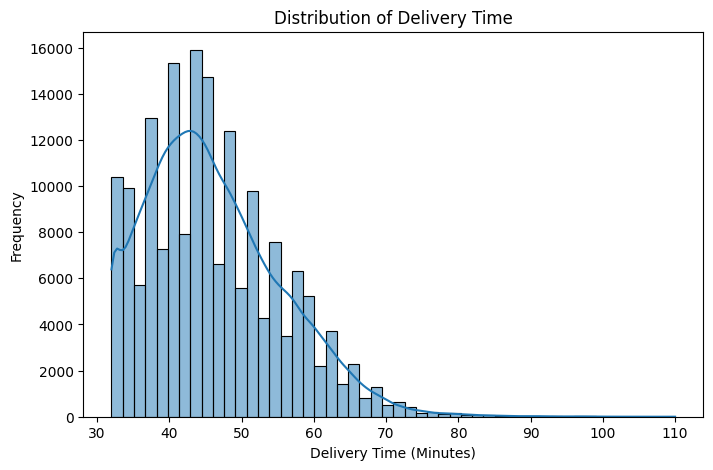

In [30]:
plt.figure(figsize=(8,5))
sns.histplot(df['delivery_time'], bins=50, kde=True)
plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Minutes)")
plt.ylabel("Frequency")
plt.show()

2. Restaurant Category Distribution

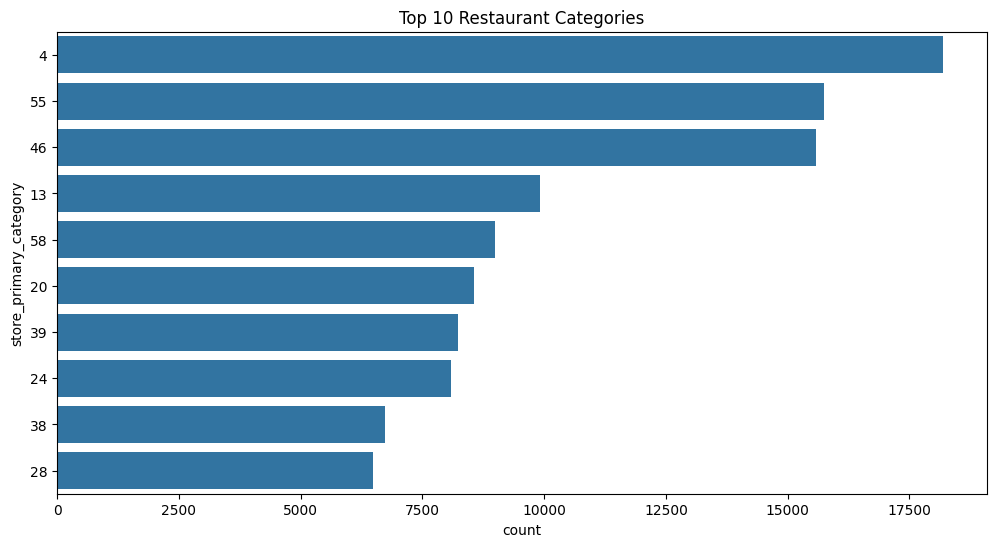

In [31]:
plt.figure(figsize=(12,6))
sns.countplot(
    y='store_primary_category',
    data=df,
    order=df['store_primary_category'].value_counts().head(10).index
)

plt.title("Top 10 Restaurant Categories")
plt.show()

3. Delivery Time vs Order Amount

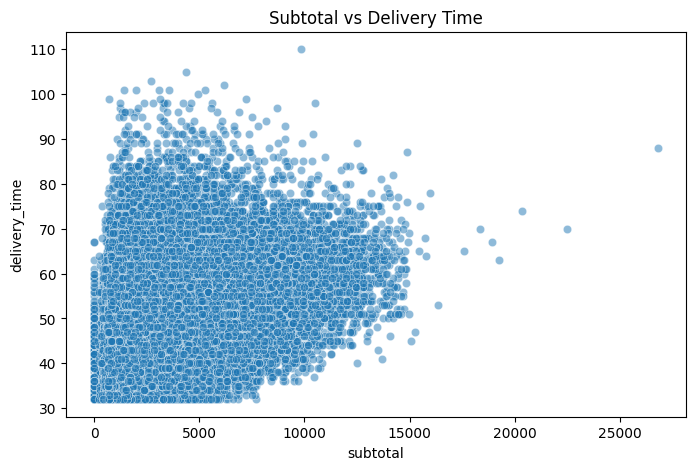

In [32]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='subtotal',
    y='delivery_time',
    data=df,
    alpha=0.5
)

plt.title("Subtotal vs Delivery Time")
plt.show()

4. Correlation Heatmap

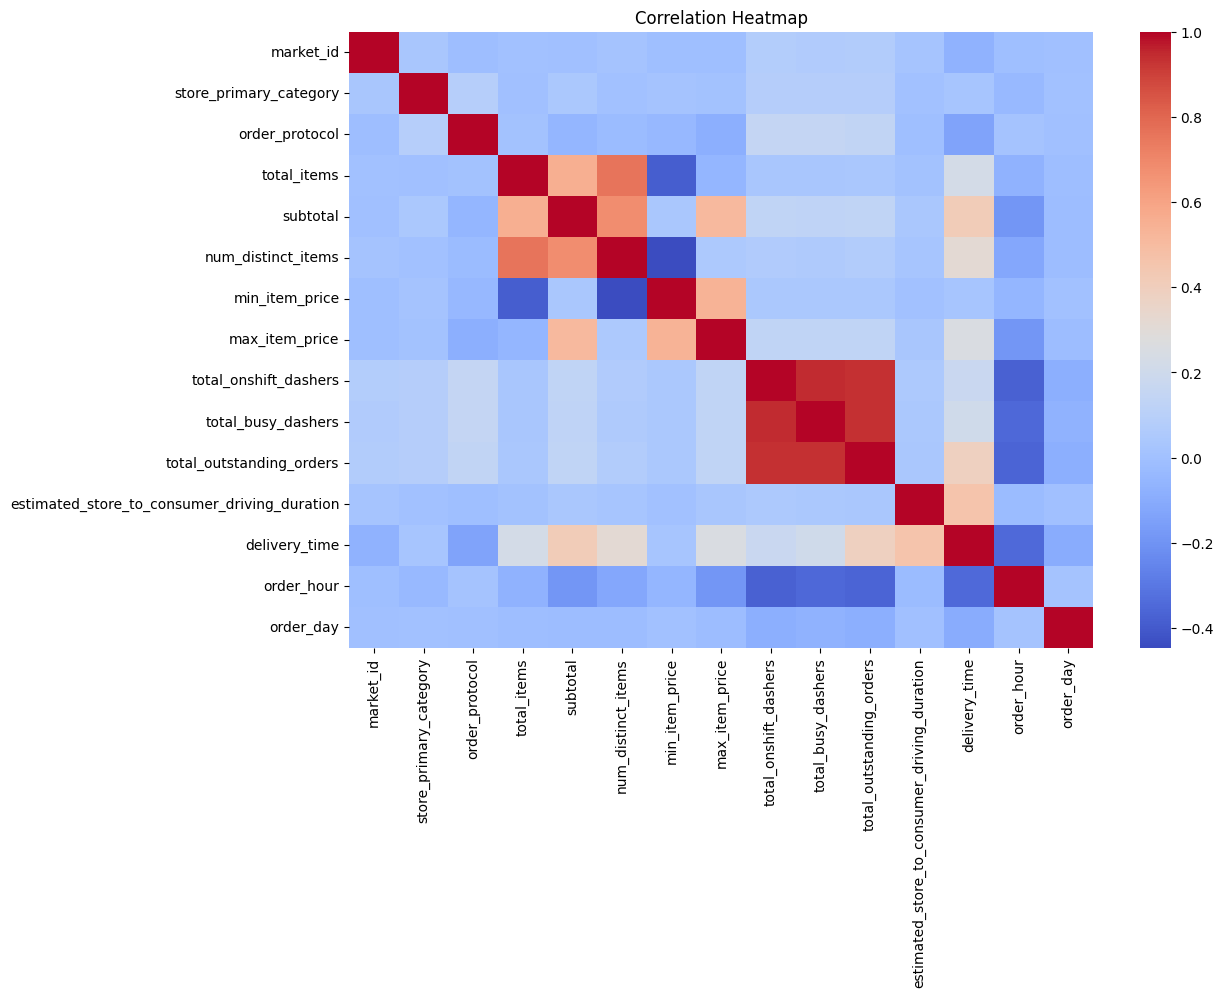

In [33]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Heatmap")
plt.show()

5. Check Outliers

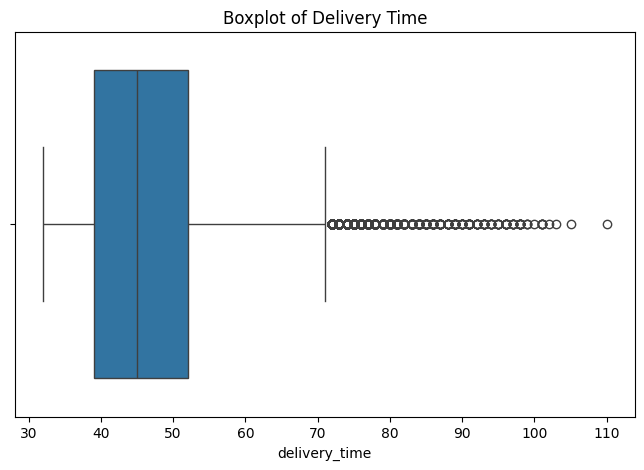

In [34]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['delivery_time'])

plt.title("Boxplot of Delivery Time")

plt.show()

6. Remove Outliers Using IQR

In [35]:
Q1 = df['delivery_time'].quantile(0.25)
Q3 = df['delivery_time'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clean = df[
    (df['delivery_time'] >= lower) &
    (df['delivery_time'] <= upper)
]

7. Compare Before vs After

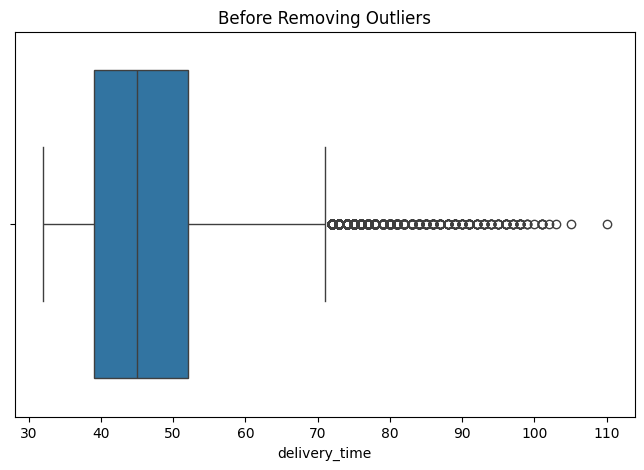

In [36]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['delivery_time'])

plt.title("Before Removing Outliers")

plt.show()

AFTER CLEANING

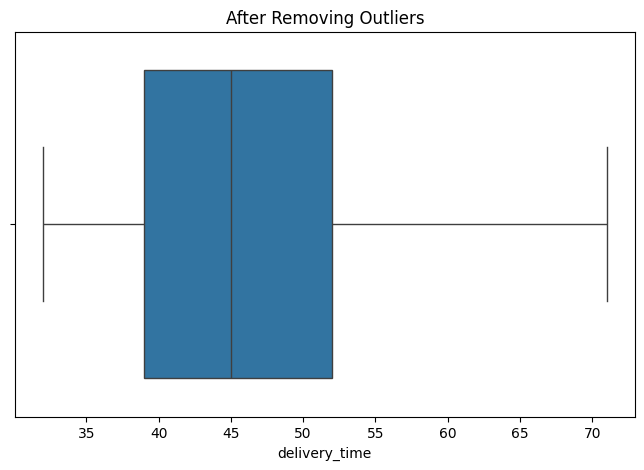

In [37]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df_clean['delivery_time'])

plt.title("After Removing Outliers")

plt.show()

Regression with Neural Networks
1. Data Splitting
Objective

To divide the dataset into training and testing sets so that the model can be trained on one portion of the data and evaluated on unseen data.

In [38]:
X = df_clean.drop(
    ['delivery_time','created_at','actual_delivery_time'],
    axis=1
)

y = df_clean['delivery_time']

TRAIN TEST SPLIT

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

2. Data Scaling
Objective

Normalize the numerical features before feeding them into the Neural Network.

In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

3. Random Forest Baseline Model
Objective

Train a classical machine learning model to compare its performance with the Neural Network.

In [43]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

EVALUATION

In [45]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("Random Forest RMSE :", rmse)

Random Forest RMSE : 1.7689903091269266


4. Neural Network Architecture
Objective

Build a Deep Neural Network capable of learning nonlinear relationships between input features and delivery time.

In [46]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential()

model.add(Dense(128,
                activation='relu',
                input_shape=(X_train.shape[1],)))

model.add(Dropout(0.2))

model.add(Dense(64,
                activation='relu'))

model.add(Dropout(0.2))

model.add(Dense(32,
                activation='relu'))

model.add(Dense(1))

5. Compile Model

In [48]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

6. Trying Different Hyperparameters

MODEL 1


In [50]:
# 64 -> 32

# Epochs = 30

# Batch Size = 64

In [ ]:
MODEL  2

In [51]:
#128 → 64 → 32

#Epochs = 50

#Batch Size = 64

MODEL 3

In [52]:
#256 → 128 → 64

#Dropout = 0.3

#Epochs = 100

7. Model Training

In [54]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    verbose=1
)

Epoch 1/50
1741/1741 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 93.0886 - mae: 5.9326 - val_loss: 5.1708 - val_mae: 1.7534
Epoch 2/50
1741/1741 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 18.7583 - mae: 3.2929 - val_loss: 3.3095 - val_mae: 1.3243
Epoch 3/50
1741/1741 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 13.1161 - mae: 2.7857 - val_loss: 2.6799 - val_mae: 1.2149
Epoch 4/50
1741/1741 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 9.6211 - mae: 2.3728 - val_loss: 2.2490 - val_mae: 1.1240
Epoch 5/50
1741/1741 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 6.6149 - mae: 1.9564 - val_loss: 1.6791 - val_mae: 0.9787
Epoch 6/50
1741/1741 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 4.3723 - mae: 1.5779 - val_loss: 1.4434 - val_mae: 0.8787
Epoch 7/50
1741/1741 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 3.1031 - mae: 1.3248 - val_loss: 1.2238 - val_mae: 0.8246
Epoch 8/50
1741/1741 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 2.5315 - mae: 1.1906 - val_loss: 1.0789 - val_mae: 0.7605
Epoch 9/50
1741/1741 ━━━━━━━━━━━━━━━━

8. Loss Curve

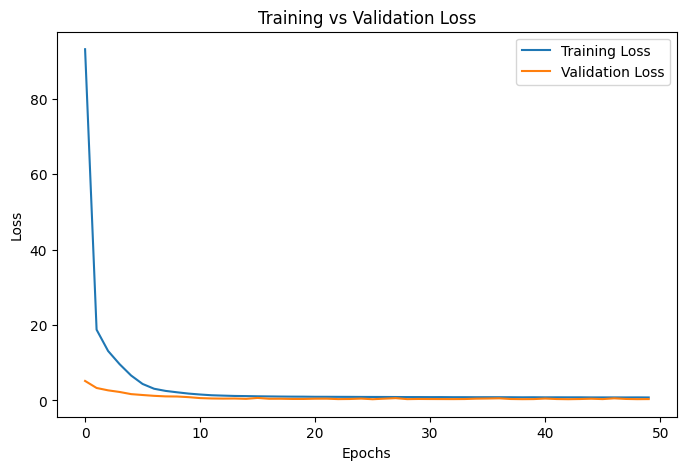

In [55]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],
         label='Training Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.title("Training vs Validation Loss")

plt.show()

9. Prediction

In [56]:
pred = model.predict(X_test)

1088/1088 ━━━━━━━━━━━━━━━━━━━━ 1s 756us/step


10. Evaluation

In [57]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

mse = mean_squared_error(y_test, pred)

rmse = np.sqrt(mse)

mae = mean_absolute_error(y_test, pred)

r2 = r2_score(y_test, pred)

print("MSE :", mse)
print("RMSE :", rmse)
print("MAE :", mae)
print("R2 Score :", r2)

MSE : 0.3665632523738274
RMSE : 0.6054446732558041
MAE : 0.47654559218677334
R2 Score : 0.9952769884789984
